In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.special import erf

In [2]:
mpl.rcParams['figure.dpi'] = 150

# Plotting $P_t(n)$

In [13]:
def read_P(filename):
    fin = open(filename, 'r')
    fin.readline()  # Skip the first line
    params_line = fin.readline().split()  # Skip the second line
    temp, lda, n0, sigma0 = float(params_line[1]), float(params_line[2]), float(params_line[3]), float(params_line[4])
    grid_line = fin.readline().split()
    grid = np.array([float(x) for x in grid_line[1:]])
    times = []
    probs_in_time = []
    while True:
        j = fin.readline()
        if not j:
            break
        line = j.split()
        times.append(float(line[0]))
        probs_in_time.append([float(x) for x in line[1:]])
    probs_in_time = np.array(probs_in_time)
    times = np.array(times)
    fin.close()
    return grid, times, probs_in_time, temp, lda, n0, sigma0

In [4]:
def plot_distr(grid, times, probs_in_time, times_to_plot):
    plt.figure()
    for i in range(len(times_to_plot)):
        index = np.argmin(np.abs(times - times_to_plot[i]))
        t = times[index]
        prob = probs_in_time[index, :]
        plt.plot(grid, prob, label="t={:.4f}".format(t))
    plt.xlabel('n')
    plt.ylabel(r'$P_t(n)$')
    plt.legend(loc='best')
    plt.show()

In [5]:
def plot_distr_compare_theory(grid, times, probs_in_time, times_to_plot, n0, sigma0):
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    plt.figure()
    for i in range(len(times_to_plot)):
        color = color_cycle[i % len(color_cycle)]
        index = np.argmin(np.abs(times - times_to_plot[i]))
        t = times[index]
        prob = probs_in_time[index, :]
        # Theoretical distribution
        normalization = np.sqrt(np.pi / 2) * sigma0 * (1 + erf(n0 / (sigma0 * np.sqrt(2))))
        theo_vals = np.zeros(len(grid))
        for i in range(len(grid)):
            n = grid[i]
            theo_vals[i] = np.exp(-np.power(n / (n + np.exp(t) * (1 - n)) - n0, 2) / 2 / sigma0 / sigma0 - t) / \
                           pow(n - 1 - n * np.exp(-t), 2) / normalization
        plt.plot(grid, prob, label="t={:.4f}".format(t), c=color)
        plt.plot(grid, theo_vals, linestyle='--', c='black')
    plt.xlabel('n')
    plt.ylabel(r'$P_t(n)$')
    plt.legend(loc='best')
    plt.show()

In [35]:
def plot_distr_compare_steady_state(grid, times, probs_in_time, times_to_plot, 
                                    temp, lda):
    plt.figure()
    for i in range(len(times_to_plot)):
        index = np.argmin(np.abs(times - times_to_plot[i]))
        t = times[index]
        prob = probs_in_time[index, :]
        plt.plot(grid, prob, label="t={:.4f}".format(t))
    Pinf = np.zeros(len(grid) - 1)
    normalization = 0.0
    for i in range(len(grid) - 2):
        n = grid[i + 1]
        Pinf[i] = np.power(n, lda / temp - 1) * np.exp(-(n - 1) * (n - 1) / 2 / temp)
        normalization += (Pinf[i] + Pinf[i + 1]) * (grid[i + 1] - grid[i]) / 2
    n = grid[-1]
    Pinf[-1] = np.power(n, lda / temp - 1) * np.exp(-(n - 1) * (n - 1) / 2 / temp)
    normalization += (Pinf[-1] + Pinf[-2]) * (grid[-1] - grid[-2]) / 2
    Pinf /= normalization
    plt.plot(grid[1:], Pinf, linestyle='--', c='black')
    plt.xlabel('n')
    plt.ylabel(r'$P_t(n)$')
    plt.legend(loc='best')
    plt.show()

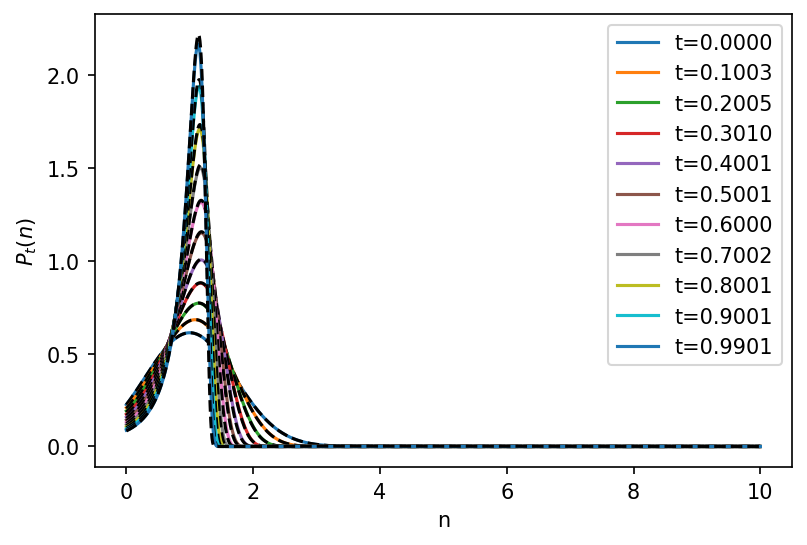

In [11]:
temp = "0.000"
lda = "0.0e+00"
nmax = "10.00"
npoints = "1000"
tmax = "1.00"
atol = "1.0e-06"
rtol = "0.0e+00"
dt0 = "1.0e-06"
n0 = "1.00"
sigma0 = "0.71"
ts = "0.0100"
maxiter = "10000"
filtersize = "5"
sigmaf = "1.000"
filename = f'Debug/FokkerPlanck_single_var_temp_{temp}_lambda_{lda}_nmax_{nmax}_npoints_{npoints}_tmax_{tmax}_atol_{atol}_rtol_{rtol}_dt0_{dt0}_n0_{n0}_sigma0_{sigma0}_ts_{ts}_maxiter_{maxiter}_filtersize_{filtersize}_sigmaf_{sigmaf}.txt'
times_to_plot = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
grid, times, prob_in_time, temp, lda, n0, sigma0 = read_P(filename)
plot_distr_compare_theory(grid, times, prob_in_time, times_to_plot, n0, sigma0)

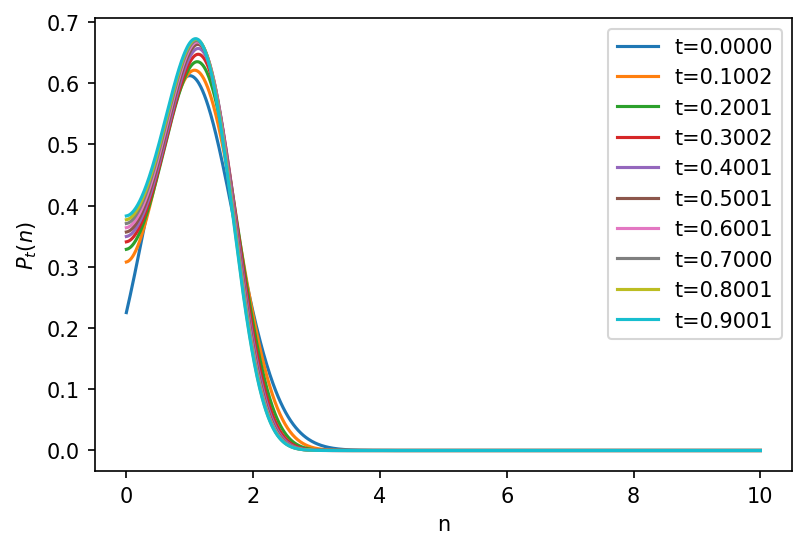

In [38]:
temp = "0.050"
lda = "1.0e-01"
nmax = "10.00"
npoints = "1000"
tmax = "1.00"
atol = "1.0e-06"
rtol = "1.0e-06"
dt0 = "1.0e-06"
n0 = "1.00"
sigma0 = "0.71"
ts = "0.0100"
maxiter = "10000"
filtersize = "5"
sigmaf = "1.000"
filename = f'Debug/FokkerPlanck_single_var_temp_{temp}_lambda_{lda}_nmax_{nmax}_npoints_{npoints}_tmax_{tmax}_atol_{atol}_rtol_{rtol}_dt0_{dt0}_n0_{n0}_sigma0_{sigma0}_ts_{ts}_maxiter_{maxiter}_filtersize_{filtersize}_sigmaf_{sigmaf}.txt'
times_to_plot = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
grid, times, prob_in_time, temp, lda, n0, sigma0 = read_P(filename)
plot_distr(grid, times, prob_in_time, times_to_plot)

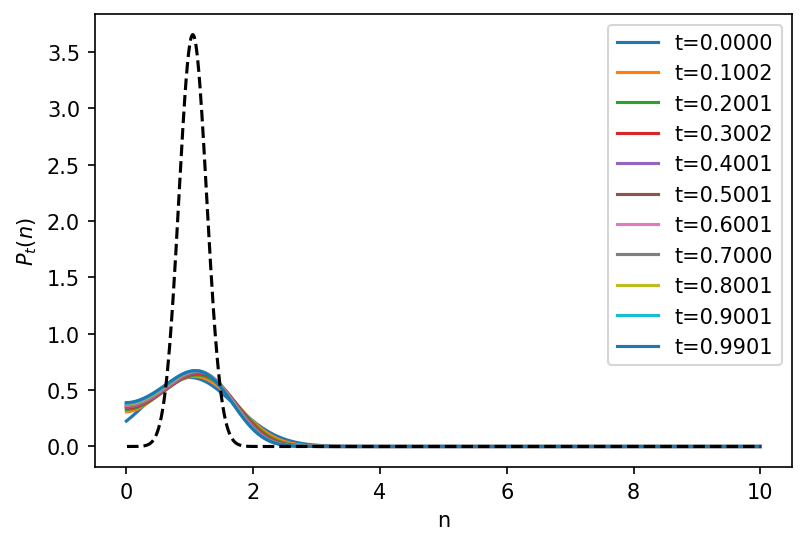

In [36]:
temp = "0.050"
lda = "1.0e-01"
nmax = "10.00"
npoints = "1000"
tmax = "1.00"
atol = "1.0e-06"
rtol = "1.0e-06"
dt0 = "1.0e-06"
n0 = "1.00"
sigma0 = "0.71"
ts = "0.0100"
maxiter = "10000"
filtersize = "5"
sigmaf = "1.000"
filename = f'Debug/FokkerPlanck_single_var_temp_{temp}_lambda_{lda}_nmax_{nmax}_npoints_{npoints}_tmax_{tmax}_atol_{atol}_rtol_{rtol}_dt0_{dt0}_n0_{n0}_sigma0_{sigma0}_ts_{ts}_maxiter_{maxiter}_filtersize_{filtersize}_sigmaf_{sigmaf}.txt'
times_to_plot = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
grid, times, prob_in_time, temp, lda, n0, sigma0 = read_P(filename)
plot_distr_compare_steady_state(grid, times, prob_in_time, times_to_plot, temp, lda)

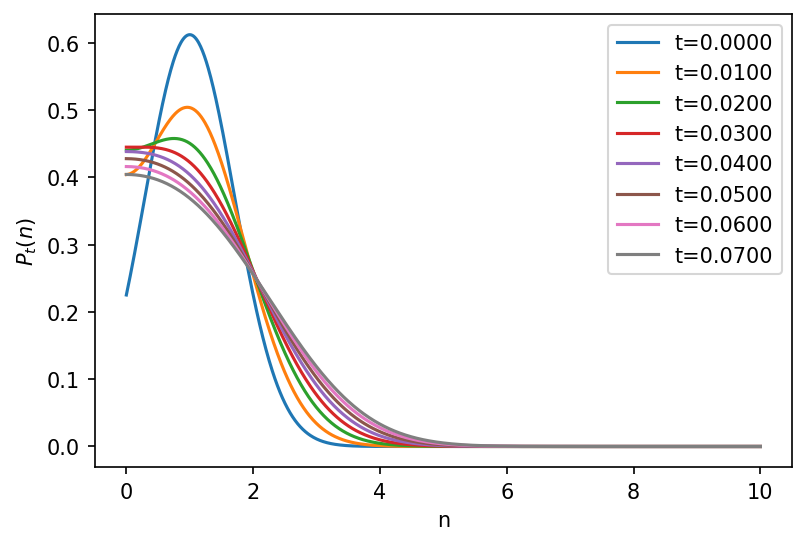

In [40]:
temp = "0.500"
lda = "1.0e-02"
nmax = "10.00"
npoints = "1000"
tmax = "1.00"
atol = "1.0e-06"
rtol = "1.0e-06"
dt0 = "1.0e-06"
n0 = "1.00"
sigma0 = "0.71"
ts = "0.0001"
maxiter = "10000"
filtersize = "5"
sigmaf = "1.000"
filename = f'Debug/FokkerPlanck_single_var_temp_{temp}_lambda_{lda}_nmax_{nmax}_npoints_{npoints}_tmax_{tmax}_atol_{atol}_rtol_{rtol}_dt0_{dt0}_n0_{n0}_sigma0_{sigma0}_ts_{ts}_maxiter_{maxiter}_filtersize_{filtersize}_sigmaf_{sigmaf}.txt'
times_to_plot = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]
grid, times, prob_in_time, temp, lda, n0, sigma0 = read_P(filename)
plot_distr(grid, times, prob_in_time, times_to_plot)

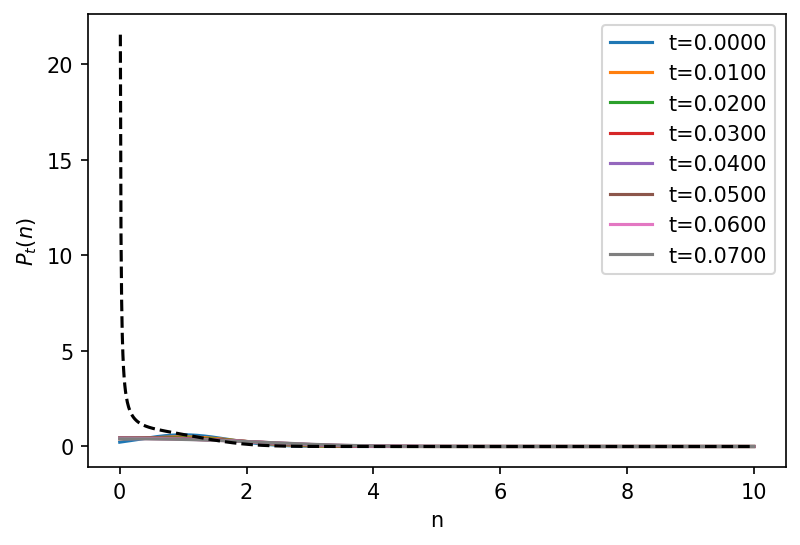

In [32]:
temp = "0.500"
lda = "1.0e-02"
nmax = "10.00"
npoints = "1000"
tmax = "1.00"
atol = "1.0e-06"
rtol = "1.0e-06"
dt0 = "1.0e-06"
n0 = "1.00"
sigma0 = "0.71"
ts = "0.0001"
maxiter = "10000"
filtersize = "5"
sigmaf = "1.000"
filename = f'Debug/FokkerPlanck_single_var_temp_{temp}_lambda_{lda}_nmax_{nmax}_npoints_{npoints}_tmax_{tmax}_atol_{atol}_rtol_{rtol}_dt0_{dt0}_n0_{n0}_sigma0_{sigma0}_ts_{ts}_maxiter_{maxiter}_filtersize_{filtersize}_sigmaf_{sigmaf}.txt'
times_to_plot = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]
grid, times, prob_in_time, temp, lda, n0, sigma0 = read_P(filename)
plot_distr_compare_steady_state(grid, times, prob_in_time, times_to_plot, temp, lda)